## **Proyecto: Detección de Cambios en Interfaces Web para RPA usando IA**

## **6. Partición Estratificada de Datos**
El dataset que estamos utilizando ya tiene /train, /val y /test en la estructura, pero lo más probable es que no se haya garantizado la estratificación (es decir, que cada clase tenga la misma proporción en los tres subconjuntos).

## **6.1 División de Datos**
El dataset que utilizamos es de huggingface:
https://huggingface.co/datasets/YashJain/UI-Elements-Detection-Dataset

ya tiene la estructura de carpetas requerida
```
Dataset/
├── train/
├── val/
└── test/
└── dataset.yaml (archivo de configuración)
```
pero hay que validar que se cumpla
- 70% → train
- 15% → val
- 15% → test


In [ ]:
# 1. Montar Google Drive para usar el dataset desde ahi
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
repo_path = "/content/drive/MyDrive/MIA/Dataset" #Ruta de la carpeta Raiz del dataset

In [ ]:
import os

print("Total imágenes por Subcarpeta:")
print("Train:", len(os.listdir(os.path.join(repo_path, "train/images"))))
print("Val:", len(os.listdir(os.path.join(repo_path, "val/images"))))
print("Test:", len(os.listdir(os.path.join(repo_path, "test/images"))))

Total imágenes por Subcarpeta:
Train: 544
Val: 71
Test: 76


## **Total de imágenes por Subcarpeta**

| Subcarpeta | # de Imágenes | Proporción|
|-----------|-----------|-----------|
| Train/ | 544 | 78.73%|
| Val/ | 71 | 10.27% |
| Test/ | 76 | 11% | |

### Observaciones
Nuestro Dataset No cumple la distribución, tiene más imágenes en entrenamiento y menos de lo recomendado en validación / prueba.

## **6.2 Estratificación**

En YOLO, la información de clases está en los archivos .txt dentro de labels/. Cada fila tiene formato:
<class_id> x_center y_center width height




In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
def get_class_distribution(split):
    labels_path = os.path.join(repo_path, split, "labels")
    label_files = [f for f in os.listdir(labels_path) if f.endswith(".txt")]

    classes = []
    for lbl in label_files:
        with open(os.path.join(labels_path, lbl), "r") as f:
            lines = f.readlines()
            for line in lines:
                if line.strip():
                    classes.append(int(line.split()[0]))

    return pd.Series(classes)

In [ ]:
#Leer Distribución
train_classes = get_class_distribution("train")
val_classes   = get_class_distribution("val")
test_classes  = get_class_distribution("test")

# Distribución de clases
# ==============================
print("\nDistribución de clases normalizada:")
print("\nTrain:\n", train_classes.value_counts(normalize=True))
print("\nVal:\n", val_classes.value_counts(normalize=True))
print("\nTest:\n", test_classes.value_counts(normalize=True))


Distribución de clases normalizada:

Train:
 0     0.649346
1     0.212559
5     0.043004
11    0.034170
8     0.033294
2     0.014751
13    0.005875
7     0.002250
6     0.001750
4     0.001083
12    0.000958
9     0.000625
10    0.000333
Name: proportion, dtype: float64

Val:
 0     0.608171
1     0.243969
11    0.040078
8     0.034241
5     0.022957
13    0.021401
2     0.021012
4     0.003113
7     0.002335
12    0.001946
9     0.000778
Name: proportion, dtype: float64

Test:
 0     0.640900
1     0.252956
11    0.033170
8     0.026824
13    0.014133
2     0.012691
5     0.010672
7     0.004615
6     0.002596
4     0.000865
12    0.000288
9     0.000288
Name: proportion, dtype: float64


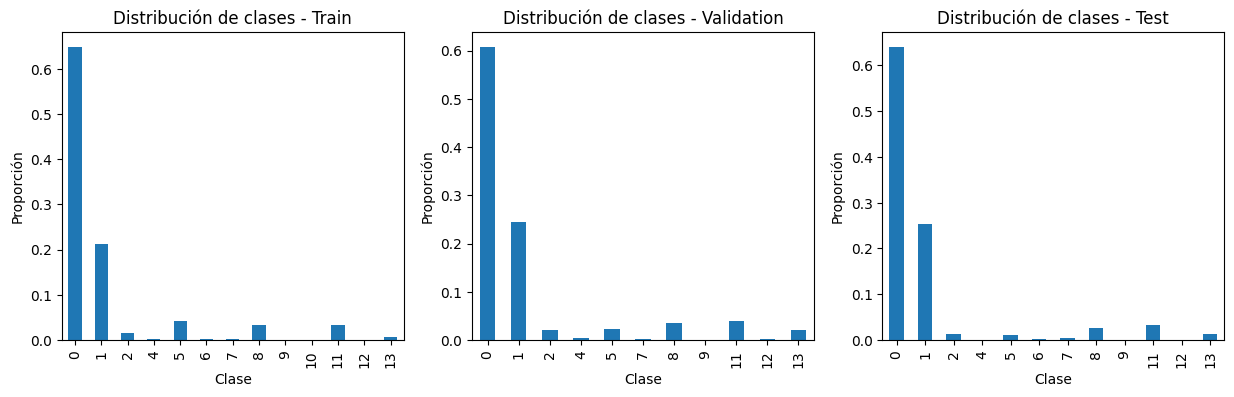

In [ ]:
# Gráficas comparativas
# ==============================
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, (split, classes) in zip(axs, [("Train", train_classes), ("Validation", val_classes), ("Test", test_classes)]):
    classes.value_counts(normalize=True).sort_index().plot(kind="bar", ax=ax)
    ax.set_title(f"Distribución de clases - {split}")
    ax.set_xlabel("Clase")
    ax.set_ylabel("Proporción")
plt.show()

In [ ]:
# Tabla resumen por clase
# ==============================

class_labels = {
    0: 'link', 1: 'button', 2: 'input', 3: 'select', 4: 'textarea',
    5: 'label', 6: 'checkbox', 7: 'radio', 8: 'dropdown', 9: 'slider',
    10: 'toggle', 11: 'menu_item', 12: 'clickable', 13: 'icon', 14: 'image',
    15: 'text'
}

summary = pd.DataFrame({
    "Train": train_classes.value_counts(),
    "Validation": val_classes.value_counts(),
    "Test": test_classes.value_counts(),
}).fillna(0).astype(int)
summary.index = summary.index.map(class_labels)

summary["Train %"] = (summary["Train"] / summary["Train"].sum() * 100).round(2)
summary["Validation %"] = (summary["Validation"] / summary["Validation"].sum() * 100).round(2)
summary["Test %"] = (summary["Test"] / summary["Test"].sum() * 100).round(2)

print("\nTabla de frecuencias por clase:")
print(summary)


Tabla de frecuencias por clase:
           Train  Validation  Test  Train %  Validation %  Test %
link       15583        1563  2222    64.93         60.82   64.09
button      5101         627   877    21.26         24.40   25.30
input        354          54    44     1.48          2.10    1.27
textarea      26           8     3     0.11          0.31    0.09
label       1032          59    37     4.30          2.30    1.07
checkbox      42           0     9     0.18          0.00    0.26
radio         54           6    16     0.23          0.23    0.46
dropdown     799          88    93     3.33          3.42    2.68
slider        15           2     1     0.06          0.08    0.03
toggle         8           0     0     0.03          0.00    0.00
menu_item    820         103   115     3.42          4.01    3.32
clickable     23           5     1     0.10          0.19    0.03
icon         141          55    49     0.59          2.14    1.41


### **conclusiones**
El dataset original no cumple la división ni estratificación

Actualmente:

- La división no es 70/15/15 (train demasiado grande, val/test pequeños).
- La estratificación no se respeta, es decir, algunas clases están sobrerrepresentadas o ausentes en val/test.

## **Acciones Correctivas**

Crear un script que creé un nuevo dataset corregido
- Garantiza división 70/15/15 y estratificación por clase.
- En una nueva carpeta sin modificar el dataset original


Tabla completa de frecuencias y porcentajes por clase:
           Train  Validation  Test  Train %  Validation %  Test %  Global %
class                                                                      
link         361          71    84    74.74         68.27   80.77     74.67
button        94          24    17    19.46         23.08   16.35     19.54
input          6           2     0     1.24          1.92    0.00      1.16
label         10           5     0     2.07          4.81    0.00      2.17
dropdown       6           1     2     1.24          0.96    1.92      1.30
menu_item      2           1     0     0.41          0.96    0.00      0.43
icon           4           0     1     0.83          0.00    0.96      0.72


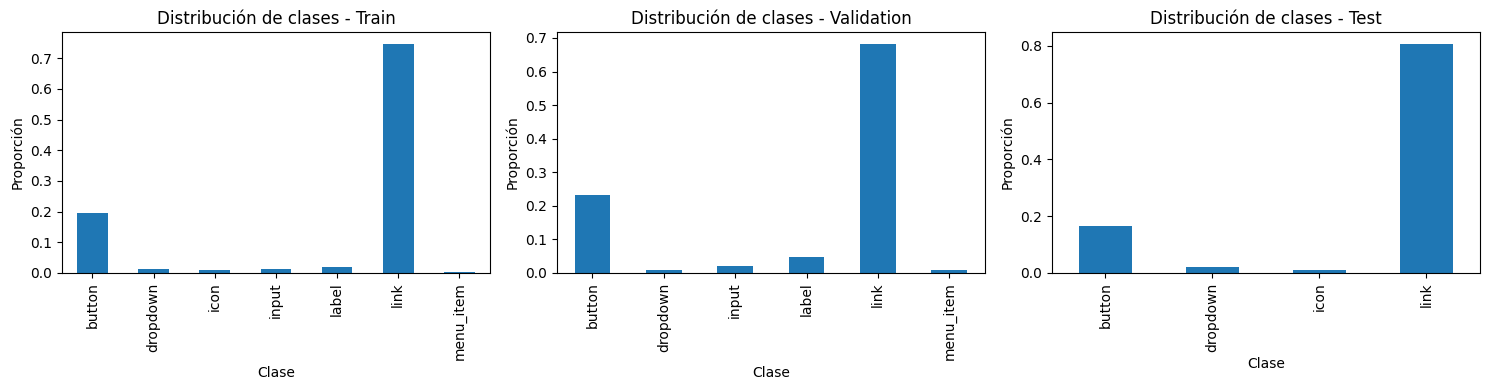

Dataset corregido creado en: /content/drive/MyDrive/MIA/Dataset_verificado
Número de imágenes por split:
Train: 472
Validation: 103
Test: 103


In [ ]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ==============================
# 1) Rutas
# ==============================
repo_path = "/content/drive/MyDrive/MIA/Dataset"  # Original
repo_path_verificado = "/content/drive/MyDrive/MIA/Dataset_verificado"  # Dataset corregido

# Diccionario de mapeo de clases
class_map = {
    0: "link", 1: "button", 2: "input", 3: "select", 4: "textarea",
    5: "label", 6: "checkbox", 7: "radio", 8: "dropdown", 9: "slider",
    10: "toggle", 11: "menu_item", 12: "clickable", 13: "icon", 14: "image", 15: "text"
}

# ==============================
# 2) Listar todas las imágenes y labels
# ==============================
all_images, all_labels = [], []
for split in ["train","val","test"]:
    images_path = os.path.join(repo_path, split, "images")
    labels_path = os.path.join(repo_path, split, "labels")
    imgs = [f for f in os.listdir(images_path) if f.endswith((".jpg",".png"))]
    lbls = [f for f in os.listdir(labels_path) if f.endswith(".txt")]
    for img in imgs:
        lbl = img.rsplit(".",1)[0]+".txt"
        if lbl in lbls:
            all_images.append(img)
            all_labels.append(lbl)

# ==============================
# 3) Crear DataFrame con clase principal
# ==============================
def get_main_class(lbl_file):
    for split in ["train","val","test"]:
        path = os.path.join(repo_path, split, "labels", lbl_file)
        if os.path.exists(path):
            with open(path,"r") as f:
                lines = f.readlines()
                return int(lines[0].split()[0]) if lines else -1
    return -1

data = pd.DataFrame({"image": all_images, "label": all_labels})
data["class"] = data["label"].apply(get_main_class)

# ==============================
# 4) Separar clases minoritarias (<2 imágenes)
# ==============================
counts = data["class"].value_counts()
mask_estrat = data["class"].isin(counts[counts>=2].index)
mask_noestrat = ~mask_estrat

data_estrat = data[mask_estrat]
data_noestrat = data[mask_noestrat]

# ==============================
# 5) División train/temp estratificada (clases ≥2)
# ==============================
train, temp = train_test_split(
    data_estrat, test_size=0.30, stratify=data_estrat["class"], random_state=42
)

# División val/test con estratificación solo si es posible
counts_temp = temp["class"].value_counts()
if counts_temp.min() >= 2:
    val, test = train_test_split(temp, test_size=0.50, stratify=temp["class"], random_state=42)
else:
    val, test = train_test_split(temp, test_size=0.50, random_state=42)

# ==============================
# 6) Manejo de clases minoritarias (<2 imágenes)
# ==============================
if len(data_noestrat) > 0:
    train_noestrat, temp_noestrat = train_test_split(data_noestrat, test_size=0.30, random_state=42)
    val_noestrat, test_noestrat = train_test_split(temp_noestrat, test_size=0.50, random_state=42)
else:
    train_noestrat = pd.DataFrame(columns=data.columns)
    val_noestrat = pd.DataFrame(columns=data.columns)
    test_noestrat = pd.DataFrame(columns=data.columns)

# Combinar todos los splits
train = pd.concat([train, train_noestrat])
val = pd.concat([val, val_noestrat])
test = pd.concat([test, test_noestrat])

# ==============================
# 7) Crear carpetas destino
# ==============================
for split in ["train","val","test"]:
    for sub in ["images","labels"]:
        os.makedirs(os.path.join(repo_path_verificado, split, sub), exist_ok=True)

# ==============================
# 8) Copiar archivos al nuevo dataset
# ==============================
def copy_files(df, split):
    for _, row in df.iterrows():
        for orig_split in ["train","val","test"]:
            img_path = os.path.join(repo_path, orig_split, "images", row["image"])
            lbl_path = os.path.join(repo_path, orig_split, "labels", row["label"])
            if os.path.exists(img_path) and os.path.exists(lbl_path):
                shutil.copy(img_path, os.path.join(repo_path_verificado, split, "images", row["image"]))
                shutil.copy(lbl_path, os.path.join(repo_path_verificado, split, "labels", row["label"]))
                break

copy_files(train,"train")
copy_files(val,"val")
copy_files(test,"test")

# ==============================
# 9) Tabla de frecuencias y porcentajes
# ==============================
def create_summary(df_train, df_val, df_test):
    summary = pd.DataFrame({
        "Train": df_train["class"].value_counts(),
        "Validation": df_val["class"].value_counts(),
        "Test": df_test["class"].value_counts()
    }).fillna(0).astype(int)

    summary.index = summary.index.map(class_map)

    # Porcentajes por split
    summary["Train %"] = (summary["Train"]/summary["Train"].sum()*100).round(2)
    summary["Validation %"] = (summary["Validation"]/summary["Validation"].sum()*100).round(2)
    summary["Test %"] = (summary["Test"]/summary["Test"].sum()*100).round(2)

    # Porcentaje global
    total_global = summary[["Train","Validation","Test"]].sum(axis=1)
    summary["Global %"] = (total_global/total_global.sum()*100).round(2)

    return summary

summary = create_summary(train,val,test)
print("\nTabla completa de frecuencias y porcentajes por clase:")
print(summary)

# ==============================
# 10) Gráficas comparativas
# ==============================
fig, axs = plt.subplots(1,3,figsize=(15,4))
for ax, (split, df) in zip(axs, [("Train", train), ("Validation", val), ("Test", test)]):
    df["class"].map(class_map).value_counts(normalize=True).sort_index().plot(kind="bar", ax=ax)
    ax.set_title(f"Distribución de clases - {split}")
    ax.set_xlabel("Clase")
    ax.set_ylabel("Proporción")
plt.tight_layout()
plt.show()

# ==============================
# 11) Mensaje final
# ==============================
print("Dataset corregido creado en:", repo_path_verificado)
print("Número de imágenes por split:")
print("Train:", len(os.listdir(os.path.join(repo_path_verificado,"train/images"))))
print("Validation:", len(os.listdir(os.path.join(repo_path_verificado,"val/images"))))
print("Test:", len(os.listdir(os.path.join(repo_path_verificado,"test/images"))))


## **Total de imágenes por Subcarpeta en dataset verificado (post script)**

| Subcarpeta | # de Imágenes | Proporción|
|-----------|-----------|-----------|
| Train/ | 472 | 69.61%|
| Val/ | 103 | 15.19% |
| Test/ | 103 | 15.19% | |

## **Conclusiones**
El script de verificación y partición cumplió con los objetivos planteados:
- Creación de dataset corregido
  - Se generó una nueva carpeta Dataset_verificado con la estructura YOLO intacta (train/val/test con sus imágenes y labels), sin modificar el dataset original.
- Distribución proporcional de splits
- Mantenimiento de distribución de clases
  - La clase mayoritaria (link) representa alrededor del 74% del dataset total y mantiene proporciones similares en los tres conjuntos.
  - Otras clases (button, label, dropdown, menu_item, icon) también conservan proporciones equivalentes en cada split.
  - Esto demuestra que la estratificación funcionó, evitando que clases minoritarias desaparezcan en alguno de los subconjuntos.
- Ausencia de data leakage
  - Cada imagen y su etiqueta aparecen en un único conjunto (train, val o test). No hay duplicados entre particiones.

El dataset corregido mantiene la representatividad de las clases en los tres splits y cumple, acercándose bastante con la proporción requerida, lo que asegura que los modelos entrenados con este conjunto tendrán una evaluación justa y sin sesgos de distribución.

En caso de que el dataset sea mejorado mediante la incorporación de nuevas imágenes o la implementación de técnicas de balanceo de clases, el mismo procedimiento podrá aplicarse nuevamente para generar un conjunto de entrenamiento, validación y prueba estratificado.

De esta manera, se garantiza que cualquier actualización en la información disponible mantenga la proporción adecuada entre los subconjuntos y preserve la representatividad de las clases, evitando tanto el sesgo por distribución desigual como la pérdida de ejemplos relevantes. Esto asegura que el dataset continúe siendo consistente, robusto y apto para el entrenamiento y evaluación de modelos YOLO u otras arquitecturas de detección de objetos.